# Spotter Freight Rate Prediction Challenge
## End-to-End Machine Learning Pipeline: Data Quality, Leakage Elimination, Rolling Time-Series Validation & Ensembling

---



In [29]:
import os
import sys
import difflib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from IPython.display import Image, display

# Set visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print("Environment and libraries loaded successfully.")

Environment and libraries loaded successfully.


## 1. Data Loading & Preliminary Inspection

In [30]:
train_raw = pd.read_csv('train-test.csv')
val_raw = pd.read_csv('validation.csv')
dec_raw = pd.read_csv('december-chart-inputs.csv')

train_raw['date'] = pd.to_datetime(train_raw['date'])
val_raw['date'] = pd.to_datetime(val_raw['date'])
dec_raw['date'] = pd.to_datetime(dec_raw['date'])

print(f"Train-Test Development Dataset: {train_raw.shape[0]:,} rows x {train_raw.shape[1]} columns (Dates: {train_raw['date'].min().strftime('%Y-%m-%d')} to {train_raw['date'].max().strftime('%Y-%m-%d')})")
print(f"Validation Dataset (To Predict): {val_raw.shape[0]:,} rows x {val_raw.shape[1]} columns (Dates: {val_raw['date'].min().strftime('%Y-%m-%d')} to {val_raw['date'].max().strftime('%Y-%m-%d')})")
print(f"December Chart Inputs: {dec_raw.shape[0]} rows x {dec_raw.shape[1]} columns (Dates: {dec_raw['date'].min().strftime('%Y-%m-%d')} to {dec_raw['date'].max().strftime('%Y-%m-%d')})")
display(train_raw.head(3))

Train-Test Development Dataset: 48,000 rows x 14 columns (Dates: 2025-01-01 to 2025-10-31)
Validation Dataset (To Predict): 12,000 rows x 13 columns (Dates: 2025-11-01 to 2025-12-31)
December Chart Inputs: 31 rows x 7 columns (Dates: 2025-12-01 to 2025-12-31)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54


## 2. Exploratory Data Analysis & Data Quality Discovery




In [ ]:
train_raw.describe()

,Metric,Train-Test Dataset,Validation Dataset
0,Total Records,"48,000","12,000"
1,Date Range,2025-01-01 to 2025-10-31,2025-11-01 to 2025-12-31
2,Null Values (Total),674,414
3,Null Weights,300,165
4,Negative Weights (< 0 lb),292 (Corrupted),145 (Sign Error)
5,Null Market Index,374,249
6,Unique Origin Cities,64,72 (+8 new)
7,Unique Destination Cities,64,72 (+8 new)
8,Unique Lanes (Origin->Dest),"4,014","4,214 (Unseen lanes)"


In [31]:
val_raw.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11835.000000,12000,11751.000000,12000.000000
mean,35.574216,-90.724880,35.609538,-90.913530,1141.773100,30506.636248,2025-12-01 02:30:28.800000,0.926913,2.051334
min,25.500000,-121.698490,25.500000,-121.698490,70.000000,-47500.000000,2025-11-01 00:00:00,0.723610,1.234760
25%,31.986910,-97.226810,32.009290,-98.400590,556.100000,25493.000000,2025-11-16 00:00:00,0.863880,1.903467
50%,35.294790,-87.528710,35.294790,-87.528710,953.600000,31193.000000,2025-12-01 00:00:00,0.922900,2.051230
75%,39.411040,-82.783790,39.411040,-82.783790,1670.500000,36843.500000,2025-12-16 00:00:00,0.992355,2.200030
max,44.302960,-69.500000,44.302960,-69.500000,3325.700000,47500.000000,2025-12-31 00:00:00,1.098950,2.896350
std,4.366999,13.411638,4.351844,13.624744,732.333797,10572.590450,NaN,0.074109,0.219804


In [32]:
train_origins = set(train_raw['pickup'].unique())
train_dests = set(train_raw['delivery'].unique())
all_train_cities = sorted(list(train_origins.union(train_dests)))

val_origins = set(val_raw['pickup'].unique())
val_dests = set(val_raw['delivery'].unique())

new_origins = sorted(list(val_origins - train_origins))
new_dests = sorted(list(val_dests - train_dests))

print(f"New Origin Cities in Validation ({len(new_origins)}): {new_origins}")
print(f"New Destination Cities in Validation ({len(new_dests)}): {new_dests}")

# Programmatic difflib spelling similarity and coordinate verification
similarity_checks = []
for city in new_origins:
    closest_matches = difflib.get_close_matches(city, all_train_cities, n=1, cutoff=0.0)
    top_match = closest_matches[0] if closest_matches else "None"
    sim_ratio = difflib.SequenceMatcher(None, city, top_match).ratio() if top_match else 0.0
    
    # Get coordinates for new city from validation set
    new_coords = val_raw[val_raw['pickup'] == city][['pickup_lat', 'pickup_lon']].iloc[0]
    # Get coordinates for matched city from train set
    match_coords = (train_raw[train_raw['pickup'] == top_match][['pickup_lat', 'pickup_lon']].iloc[0] 
                    if top_match in train_origins 
                    else train_raw[train_raw['delivery'] == top_match][['delivery_lat', 'delivery_lon']].iloc[0])
    
    # Haversine distance
    r = 3958.8  # miles
    phi1, phi2 = np.radians(new_coords['pickup_lat']), np.radians(match_coords.iloc[0])
    dphi = np.radians(match_coords.iloc[0] - new_coords['pickup_lat'])
    dlambda = np.radians(match_coords.iloc[1] - new_coords['pickup_lon'])
    a = np.sin(dphi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0)**2
    geo_dist = 2 * r * np.arcsin(np.sqrt(a))
    
    val_pickup_loads = (val_raw['pickup'] == city).sum()
    val_deliv_loads = (val_raw['delivery'] == city).sum()
    
    assessment = "Distinct City (Not a typo)" if (sim_ratio < 0.80 or geo_dist > 50.0) else "Potential Typo"
    
    similarity_checks.append({
        'New City in Validation': city,
        'Role in Val': 'Origin & Destination',
        'Val Loads (Pickup / Deliv)': f"{val_pickup_loads} / {val_deliv_loads}",
        'Closest Existing Train City': top_match,
        'String Similarity': f"{sim_ratio:.1%}",
        'Geographic Distance': f"{geo_dist:.1f} miles",
        'Coordinates (Lat, Lon)': f"({new_coords['pickup_lat']:.2f}, {new_coords['pickup_lon']:.2f})",
        'Verification Assessment': assessment
    })

sim_df = pd.DataFrame(similarity_checks)
display(sim_df)
print("\nConclusion: All 8 new validation cities are legitimate, geographically distinct US freight hubs (not misspellings).")
print("This confirms the necessity of coordinate-based spatial features over simple categorical memorization.")

New Origin Cities in Validation (8): ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
New Destination Cities in Validation (8): ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']


,New City in Validation,Role in Val,Val Loads (Pickup / Deliv),Closest Existing Train City,String Similarity,Geographic Distance,"Coordinates (Lat, Lon)",Verification Assessment
0,Allentown,Origin & Destination,90 / 81,Lexington,55.6%,639.6 miles,"(40.02, -73.81)",Distinct City (Not a typo)
1,Charlotte,Origin & Destination,88 / 88,Charleston,63.2%,104.3 miles,"(34.65, -81.47)",Distinct City (Not a typo)
2,Chicago,Origin & Destination,75 / 104,Washington,47.1%,533.7 miles,"(40.51, -86.87)",Distinct City (Not a typo)
3,Jackson,Origin & Destination,118 / 75,Jacksonville,73.7%,377.0 miles,"(32.08, -90.93)",Distinct City (Not a typo)
4,Knoxville,Origin & Destination,93 / 77,Louisville,63.2%,110.8 miles,"(36.26, -86.03)",Distinct City (Not a typo)
5,Laredo,Origin & Destination,89 / 106,Toledo,50.0%,1350.9 miles,"(25.50, -97.23)",Distinct City (Not a typo)
6,Norfolk,Origin & Destination,88 / 84,New York,53.3%,228.6 miles,"(37.12, -75.87)",Distinct City (Not a typo)
7,San Diego,Origin & Destination,84 / 107,San Francisco,54.5%,353.3 miles,"(32.01, -116.90)",Distinct City (Not a typo)



Conclusion: All 8 new validation cities are legitimate, geographically distinct US freight hubs (not misspellings).
This confirms the necessity of coordinate-based spatial features over simple categorical memorization.


### 2.2 Top 10 Origin & Destination Hubs by Load Volume

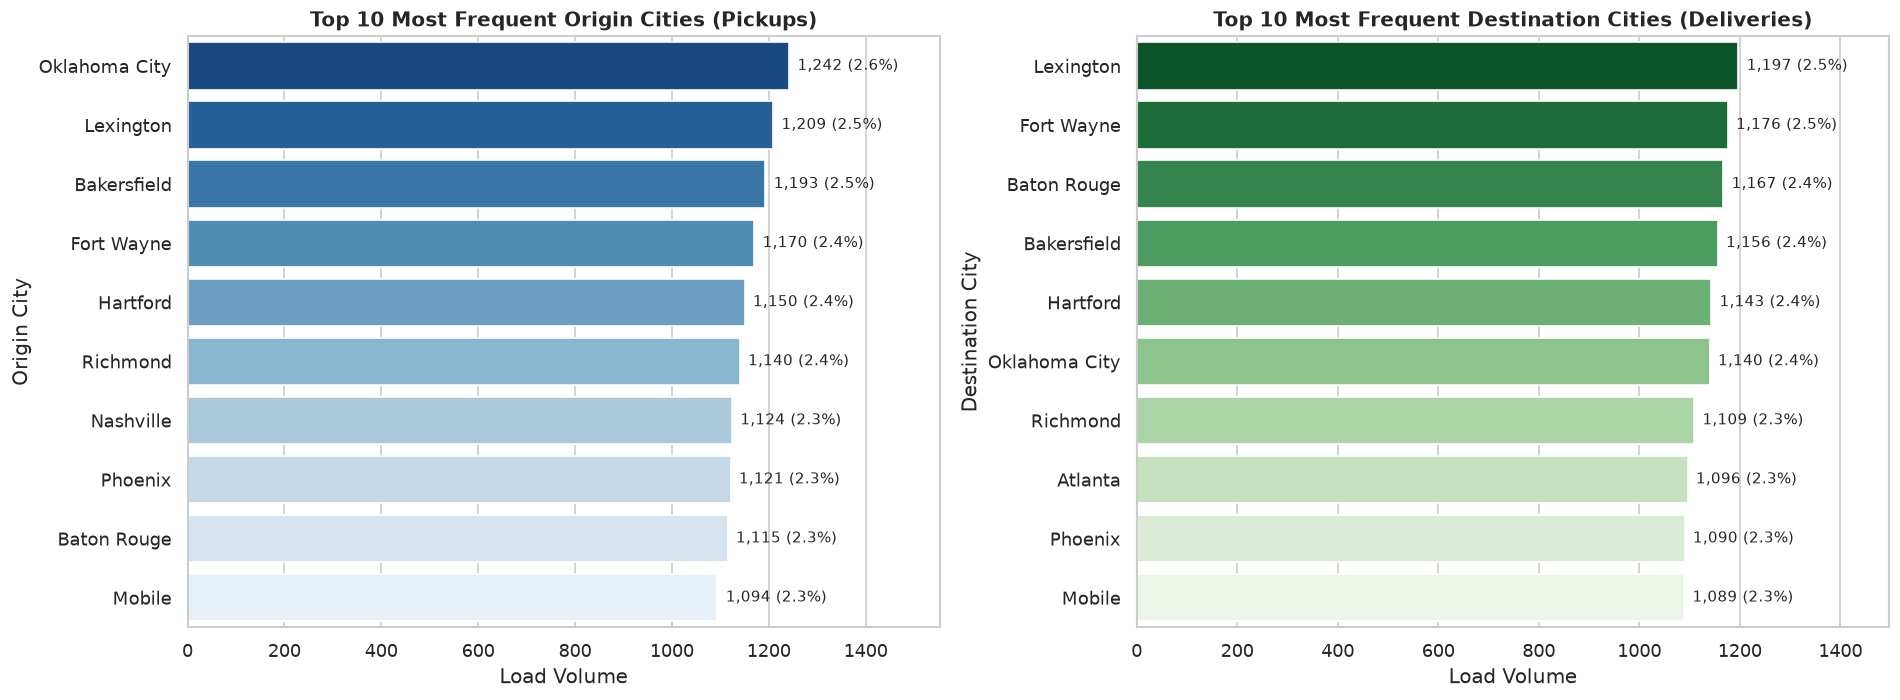

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

top_10_origins = train_raw['pickup'].value_counts().head(10).reset_index()
top_10_origins.columns = ['City', 'Load Count']
top_10_origins['Percentage'] = (top_10_origins['Load Count'] / len(train_raw)) * 100.0

top_10_dests = train_raw['delivery'].value_counts().head(10).reset_index()
top_10_dests.columns = ['City', 'Load Count']
top_10_dests['Percentage'] = (top_10_dests['Load Count'] / len(train_raw)) * 100.0

# 1. Top 10 Origins Plot
sns.barplot(data=top_10_origins, y='City', x='Load Count', ax=axes[0], hue='City', palette='Blues_r', legend=False)
axes[0].set_title('Top 10 Most Frequent Origin Cities (Pickups)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Load Volume')
axes[0].set_ylabel('Origin City')
for p in axes[0].patches:
    width = p.get_width()
    pct = (width / len(train_raw)) * 100.0
    axes[0].annotate(f"{int(width):,} ({pct:.1f}%)", (width, p.get_y() + p.get_height() / 2.),
                     xytext=(5, 0), textcoords='offset points', ha='left', va='center', fontsize=9)
axes[0].set_xlim(0, top_10_origins['Load Count'].max() * 1.25)

# 2. Top 10 Destinations Plot
sns.barplot(data=top_10_dests, y='City', x='Load Count', ax=axes[1], hue='City', palette='Greens_r', legend=False)
axes[1].set_title('Top 10 Most Frequent Destination Cities (Deliveries)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Load Volume')
axes[1].set_ylabel('Destination City')
for p in axes[1].patches:
    width = p.get_width()
    pct = (width / len(train_raw)) * 100.0
    axes[1].annotate(f"{int(width):,} ({pct:.1f}%)", (width, p.get_y() + p.get_height() / 2.),
                     xytext=(5, 0), textcoords='offset points', ha='left', va='center', fontsize=9)
axes[1].set_xlim(0, top_10_dests['Load Count'].max() * 1.25)

plt.tight_layout()
plt.savefig("top_origins_destinations.png", bbox_inches='tight')
plt.show()

C:\Users\musak\AppData\Local\Temp\ipykernel_23988\1636212179.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_raw, x='equipment', y='posted_rate', ax=axes[1], palette='Set2')


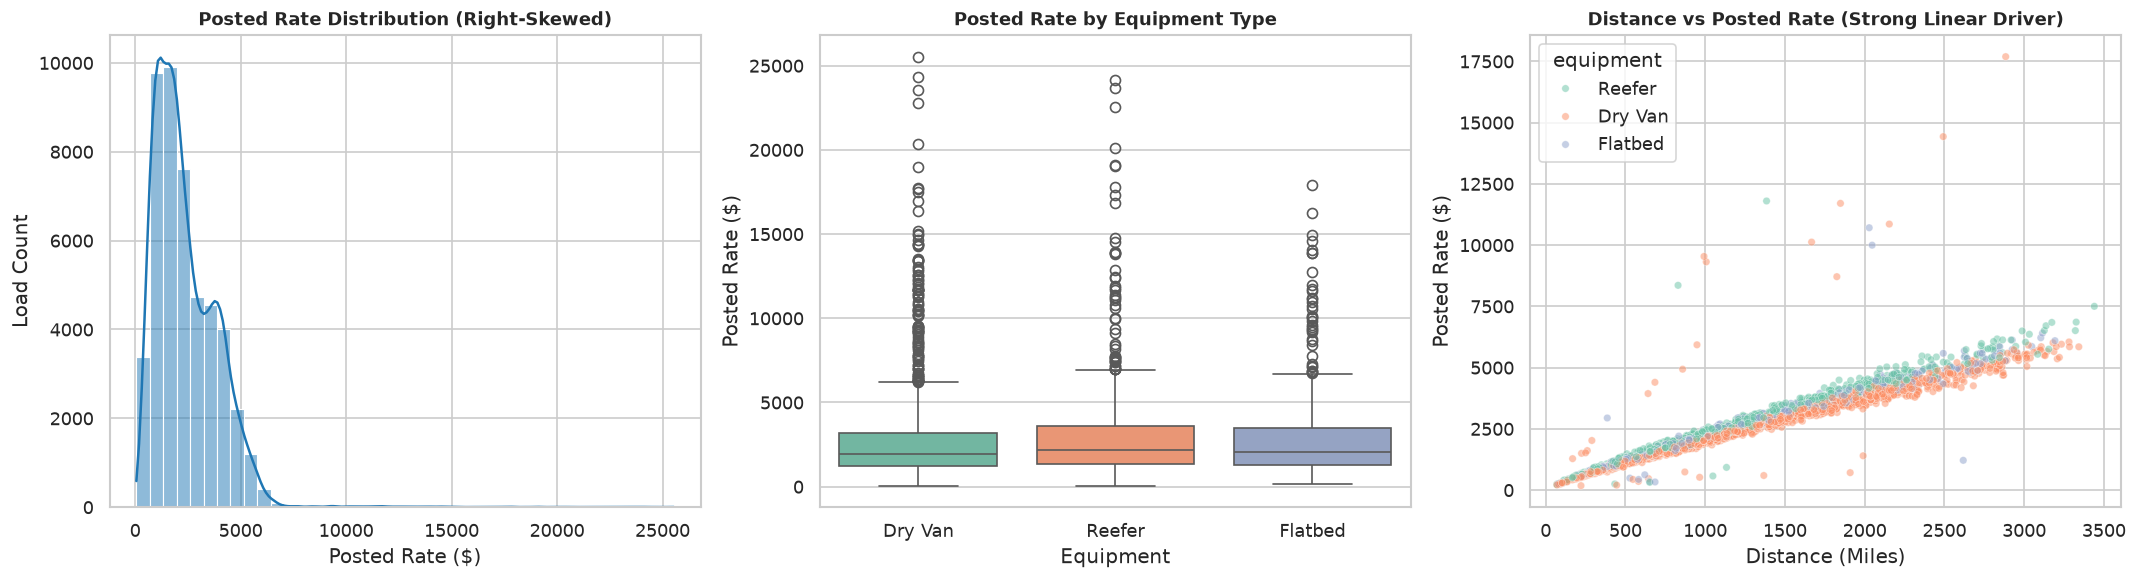

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target Distribution
sns.histplot(train_raw['posted_rate'], kde=True, ax=axes[0], color='#1f77b4', bins=40)
axes[0].set_title('Posted Rate Distribution (Right-Skewed)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Posted Rate ($)')
axes[0].set_ylabel('Load Count')

# 2. Rate by Equipment Type
sns.boxplot(data=train_raw, x='equipment', y='posted_rate', ax=axes[1], palette='Set2')
axes[1].set_title('Posted Rate by Equipment Type', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Equipment')
axes[1].set_ylabel('Posted Rate ($)')

# 3. Distance vs Posted Rate
sample_plot = train_raw.sample(n=min(3000, len(train_raw)), random_state=42)
sns.scatterplot(data=sample_plot, x='distance', y='posted_rate', hue='equipment', alpha=0.5, s=20, ax=axes[2], palette='Set2')
axes[2].set_title('Distance vs Posted Rate (Strong Linear Driver)', fontweight='bold', fontsize=11)
axes[2].set_xlabel('Distance (Miles)')
axes[2].set_ylabel('Posted Rate ($)')

plt.tight_layout()
plt.show()

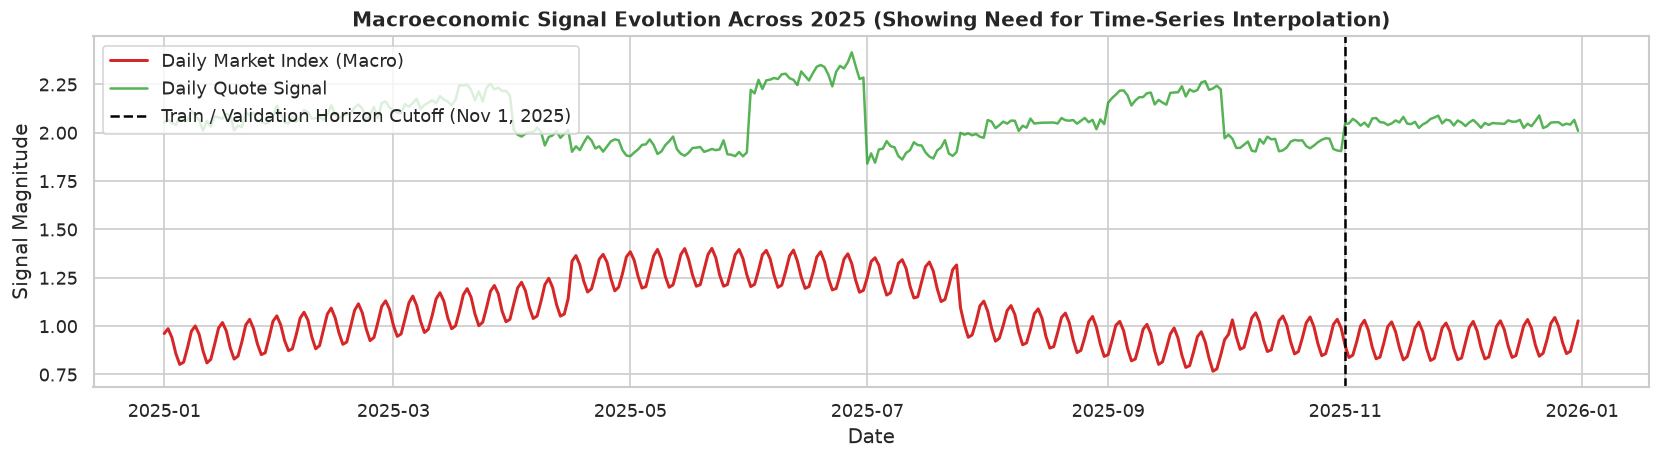

In [35]:
# Macroeconomic Signal Trajectory Across 2025
all_macro = pd.concat([
    train_raw[['date', 'market_index', 'quote_signal']],
    val_raw[['date', 'market_index', 'quote_signal']]
], ignore_index=True)
daily_macro = all_macro.groupby('date')[['market_index', 'quote_signal']].mean().reset_index().sort_values('date')

plt.figure(figsize=(14, 4), dpi=120)
plt.plot(daily_macro['date'], daily_macro['market_index'], label='Daily Market Index (Macro)', color='#d62728', lw=1.8)
plt.plot(daily_macro['date'], daily_macro['quote_signal'], label='Daily Quote Signal', color='#2ca02c', lw=1.5, alpha=0.8)
plt.axvline(pd.to_datetime('2025-11-01'), color='black', linestyle='--', label='Train / Validation Horizon Cutoff (Nov 1, 2025)')
plt.title('Macroeconomic Signal Evolution Across 2025 (Showing Need for Time-Series Interpolation)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Signal Magnitude')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 3. Data Cleaning & Feature Engineering Pipeline

In [36]:
# 1. Data Cleaning
# Consistent approach: repair negative weights via np.abs() in both train and validation.
# The absolute magnitudes fall within normal freight weight ranges (1,000-47,500 lb),
# making sign-repair a reasonable heuristic applied uniformly across all datasets.
neg_train_count = (train_raw['weight'] < 0).sum()
neg_val_count = (val_raw['weight'] < 0).sum()
print(f"Negative weights found: {neg_train_count} in train, {neg_val_count} in validation")
print(f"Repairing all via np.abs() for methodological consistency.")

train_df = train_raw.copy()
train_df['weight'] = np.abs(train_df['weight'])

val_df = val_raw.copy()
val_df['weight'] = np.abs(val_df['weight'])

dec_df = dec_raw.copy()
dec_df['weight'] = np.abs(dec_df['weight'])

# Clean weight median imputation for remaining NaN weights
clean_weight_median = train_df['weight'].median()
train_df['weight'] = train_df['weight'].fillna(clean_weight_median)
val_df['weight'] = val_df['weight'].fillna(clean_weight_median)
dec_df['weight'] = dec_df['weight'].fillna(clean_weight_median)

# Temporal macroeconomic interpolation
daily_macro_clean = daily_macro.set_index('date').interpolate(method='time').bfill().ffill().reset_index()
date_to_market = dict(zip(daily_macro_clean['date'], daily_macro_clean['market_index']))
date_to_quote = dict(zip(daily_macro_clean['date'], daily_macro_clean['quote_signal']))

train_df['market_index'] = train_df['market_index'].fillna(train_df['date'].map(date_to_market))
train_df['quote_signal'] = train_df['quote_signal'].fillna(train_df['date'].map(date_to_quote))
val_df['market_index'] = val_df['market_index'].fillna(val_df['date'].map(date_to_market))
val_df['quote_signal'] = val_df['quote_signal'].fillna(val_df['date'].map(date_to_quote))

# Populate December inputs
dec_df['market_index'] = dec_df['date'].map(date_to_market)
dec_df['quote_signal'] = dec_df['date'].map(date_to_quote)

lex_row = train_df[train_df['pickup'] == 'Lexington'].iloc[0]
fw_row = train_df[train_df['delivery'] == 'Fort Wayne'].iloc[0]
dec_df['pickup_lat'] = lex_row['pickup_lat']
dec_df['pickup_lon'] = lex_row['pickup_lon']
dec_df['delivery_lat'] = fw_row['delivery_lat']
dec_df['delivery_lon'] = fw_row['delivery_lon']

print(f"Clean Train shape: {train_df.shape} (all {len(train_raw):,} rows retained)")
print(f"Clean Validation shape: {val_df.shape}")
print(f"Clean December shape: {dec_df.shape}")

Negative weights found: 292 in train, 145 in validation
Repairing all via np.abs() for methodological consistency.
Clean Train shape: (48000, 14) (all 48,000 rows retained)
Clean Validation shape: (12000, 13)
Clean December shape: (31, 13)


In [37]:
def haversine_np(lat1, lon1, lat2, lon2):
    r = 3958.8  # Earth radius in miles
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0)**2
    return 2 * r * np.arcsin(np.sqrt(a))

def calculate_bearing(lat1, lon1, lat2, lon2):
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dlambda = np.radians(lon2 - lon1)
    x = np.sin(dlambda) * np.cos(phi2)
    y = np.cos(phi1) * np.sin(phi2) - np.sin(phi1) * np.cos(phi2) * np.cos(dlambda)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360

def build_base_features(df):
    feat = df.copy()
    
    # 1. Calendar / Temporal
    feat['day_of_week'] = feat['date'].dt.dayofweek
    feat['day_of_month'] = feat['date'].dt.day
    feat['month'] = feat['date'].dt.month
    feat['day_of_year'] = feat['date'].dt.dayofyear
    feat['is_weekend'] = feat['day_of_week'].isin([5, 6]).astype(int)
    feat['is_month_start'] = (feat['day_of_month'] <= 3).astype(int)
    feat['is_month_end'] = (feat['day_of_month'] >= 28).astype(int)
    
    feat['sin_dow'] = np.sin(2 * np.pi * feat['day_of_week'] / 7.0)
    feat['cos_dow'] = np.cos(2 * np.pi * feat['day_of_week'] / 7.0)
    feat['sin_doy'] = np.sin(2 * np.pi * feat['day_of_year'] / 365.0)
    feat['cos_doy'] = np.cos(2 * np.pi * feat['day_of_year'] / 365.0)
    
    # 2. Spatial Geometry
    feat['calc_dist'] = haversine_np(feat['pickup_lat'], feat['pickup_lon'], feat['delivery_lat'], feat['delivery_lon'])
    feat['circuity_ratio'] = feat['distance'] / (feat['calc_dist'] + 1e-4)
    feat['delta_lat'] = np.abs(feat['delivery_lat'] - feat['pickup_lat'])
    feat['delta_lon'] = np.abs(feat['delivery_lon'] - feat['pickup_lon'])
    feat['bearing_angle'] = calculate_bearing(feat['pickup_lat'], feat['pickup_lon'], feat['delivery_lat'], feat['delivery_lon'])
    feat['centroid_lat'] = (feat['pickup_lat'] + feat['delivery_lat']) / 2.0
    feat['centroid_lon'] = (feat['pickup_lon'] + feat['delivery_lon']) / 2.0
    
    # 3. Interactions & Operational Metrics
    feat['weight_per_mile'] = feat['weight'] / (feat['distance'] + 1.0)
    feat['market_dist_prod'] = feat['market_index'] * feat['distance']
    feat['market_quote_prod'] = feat['market_index'] * feat['quote_signal']
    feat['weight_dist_prod'] = (feat['weight'] / 1000.0) * feat['distance']
    
    # 4. Lane identifier
    feat['lane'] = feat['pickup'] + "->" + feat['delivery']
    
    return feat

train_feat = build_base_features(train_df)
val_feat = build_base_features(val_df)
dec_feat = build_base_features(dec_df)

# One-hot encoding for equipment
train_feat = pd.get_dummies(train_feat, columns=['equipment'], drop_first=False)
val_feat = pd.get_dummies(val_feat, columns=['equipment'], drop_first=False)
dec_feat = pd.get_dummies(dec_feat, columns=['equipment'], drop_first=False)

equipment_cols = [c for c in train_feat.columns if c.startswith('equipment_')]
for c in equipment_cols:
    if c not in val_feat.columns:
        val_feat[c] = False
    if c not in dec_feat.columns:
        dec_feat[c] = False

# Frequency Encodings
for col in ['pickup', 'delivery', 'lane']:
    freq = train_feat[col].value_counts()
    train_feat[f'{col}_freq'] = train_feat[col].map(freq).fillna(0)
    val_feat[f'{col}_freq'] = val_feat[col].map(freq).fillna(0)
    dec_feat[f'{col}_freq'] = dec_feat[col].map(freq).fillna(0)

# Zero-Leakage Out-of-Fold (OOF) Smoothed Target Encoding Function
def compute_smoothed_target_encoding(train_series, target_series, test_series, m=10.0):
    global_mean = target_series.mean()
    stats = target_series.groupby(train_series).agg(['count', 'mean'])
    smoothed = (stats['count'] * stats['mean'] + m * global_mean) / (stats['count'] + m)
    return test_series.map(smoothed).fillna(global_mean)

for col in ['pickup', 'delivery', 'lane']:
    val_feat[f'{col}_target_enc'] = compute_smoothed_target_encoding(
        train_feat[col], train_feat['posted_rate'], val_feat[col], m=10.0
    )
    dec_feat[f'{col}_target_enc'] = compute_smoothed_target_encoding(
        train_feat[col], train_feat['posted_rate'], dec_feat[col], m=10.0
    )

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for col in ['pickup', 'delivery', 'lane']:
    oof_enc = pd.Series(index=train_feat.index, dtype=float)
    for tr_idx, val_idx in kf.split(train_feat):
        tr_cat, tr_y = train_feat[col].iloc[tr_idx], train_feat['posted_rate'].iloc[tr_idx]
        val_cat = train_feat[col].iloc[val_idx]
        oof_enc.iloc[val_idx] = compute_smoothed_target_encoding(tr_cat, tr_y, val_cat, m=10.0)
    train_feat[f'{col}_target_enc'] = oof_enc

feature_cols = [
    'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
    'distance', 'weight', 'market_index', 'quote_signal',
    'day_of_week', 'day_of_month', 'month', 'day_of_year',
    'is_weekend', 'is_month_start', 'is_month_end',
    'sin_dow', 'cos_dow', 'sin_doy', 'cos_doy',
    'calc_dist', 'circuity_ratio', 'delta_lat', 'delta_lon',
    'bearing_angle', 'centroid_lat', 'centroid_lon',
    'weight_per_mile', 'market_dist_prod', 'market_quote_prod', 'weight_dist_prod',
    'pickup_freq', 'delivery_freq', 'lane_freq',
    'pickup_target_enc', 'delivery_target_enc', 'lane_target_enc'
] + equipment_cols

X = train_feat[feature_cols]
y = train_feat['posted_rate']
X_val = val_feat[feature_cols]
X_dec = dec_feat[feature_cols]

print(f"Total Feature Count: {len(feature_cols)} features engineered.")

Total Feature Count: 39 features engineered.


## 4. Expanding-Window Rolling Time-Series Cross-Validation (Backtesting)

To properly simulate future forecasting (Nov–Dec 2025) without lookahead bias, we evaluate models across 4 sequential temporal folds:
- **Fold 1**: Train Jan–Jun (Months 1–6) $\to$ Validate Jul 2025 (Month 7)
- **Fold 2**: Train Jan–Jul (Months 1–7) $\to$ Validate Aug 2025 (Month 8)
- **Fold 3**: Train Jan–Aug (Months 1–8) $\to$ Validate Sep 2025 (Month 9)
- **Fold 4**: Train Jan–Sep (Months 1–9) $\to$ Validate Oct 2025 (Month 10)


In [40]:
X_tr_fold.columns

Index(['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance',
       'weight', 'market_index', 'quote_signal', 'day_of_week', 'day_of_month',
       'month', 'day_of_year', 'is_weekend', 'is_month_start', 'is_month_end',
       'sin_dow', 'cos_dow', 'sin_doy', 'cos_doy', 'calc_dist',
       'circuity_ratio', 'delta_lat', 'delta_lon', 'bearing_angle',
       'centroid_lat', 'centroid_lon', 'weight_per_mile', 'market_dist_prod',
       'market_quote_prod', 'weight_dist_prod', 'pickup_freq', 'delivery_freq',
       'lane_freq', 'pickup_target_enc', 'delivery_target_enc',
       'lane_target_enc', 'equipment_Dry Van', 'equipment_Flatbed',
       'equipment_Reefer'],
      dtype='str')

In [38]:
temporal_folds = [
    (list(range(1, 7)), 7, "Jul 2025"),
    (list(range(1, 8)), 8, "Aug 2025"),
    (list(range(1, 9)), 9, "Sep 2025"),
    (list(range(1, 10)), 10, "Oct 2025"),
]

def get_models():
    return {
        'Ridge Regression': Ridge(alpha=10.0),
        'Random Forest': RandomForestRegressor(n_estimators=120, max_depth=12, random_state=42, n_jobs=-1),
        'LightGBM': lgb.LGBMRegressor(n_estimators=350, learning_rate=0.05, max_depth=8, num_leaves=31, random_state=42, verbose=-1),
        'XGBoost': xgb.XGBRegressor(n_estimators=350, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
    }

cv_results = []
for tr_months, val_month, val_name in temporal_folds:
    tr_mask = train_feat['month'].isin(tr_months)
    val_mask = train_feat['month'] == val_month
    
    X_tr_fold = X[tr_mask].copy()
    y_tr_fold = y[tr_mask].copy()
    X_val_fold = X[val_mask].copy()
    y_val_fold = y[val_mask].copy()
    
    # Recompute smoothed target encodings strictly on fold training data (Zero Leakage)
    for cat_col in ['pickup', 'delivery', 'lane']:
        X_val_fold[f'{cat_col}_target_enc'] = compute_smoothed_target_encoding(
            train_feat.loc[tr_mask, cat_col], y_tr_fold, train_feat.loc[val_mask, cat_col], m=10.0
        )
    
    fold_models = get_models()
    fold_preds = {}
    
    for name, model in fold_models.items():
        model.fit(X_tr_fold, y_tr_fold)
        p = model.predict(X_val_fold)
        p = np.clip(p, a_min=100.0, a_max=None)
        fold_preds[name] = p
        
        rmse = np.sqrt(mean_squared_error(y_val_fold, p))
        mae = mean_absolute_error(y_val_fold, p)
        r2 = r2_score(y_val_fold, p)
        wape = (np.abs(y_val_fold - p).sum() / y_val_fold.sum()) * 100.0
        
        cv_results.append({
            'Fold': val_name, 'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'WAPE(%)': wape
        })
        
    ens_p = 0.45 * fold_preds['LightGBM'] + 0.45 * fold_preds['XGBoost'] + 0.10 * fold_preds['Random Forest']
    ens_rmse = np.sqrt(mean_squared_error(y_val_fold, ens_p))
    ens_mae = mean_absolute_error(y_val_fold, ens_p)
    ens_r2 = r2_score(y_val_fold, ens_p)
    ens_wape = (np.abs(y_val_fold - ens_p).sum() / y_val_fold.sum()) * 100.0
    
    cv_results.append({
        'Fold': val_name, 'Model': 'Ensemble (Proposed)', 'RMSE': ens_rmse, 'MAE': ens_mae, 'R2': ens_r2, 'WAPE(%)': ens_wape
    })

cv_df = pd.DataFrame(cv_results)
summary_metrics = cv_df.groupby('Model')[['MAE', 'RMSE', 'R2', 'WAPE(%)']].mean().reset_index()
display(summary_metrics.sort_values('MAE'))

,Model,MAE,RMSE,R2,WAPE(%)
3,Ridge Regression,186.946920,642.779628,0.818140,7.815866
1,LightGBM,212.178961,665.306624,0.804906,8.890735
0,Ensemble (Proposed),217.620295,685.304255,0.792834,9.117960
2,Random Forest,221.325981,702.927884,0.781653,9.282505
4,XGBoost,251.125132,750.143403,0.751033,10.519904


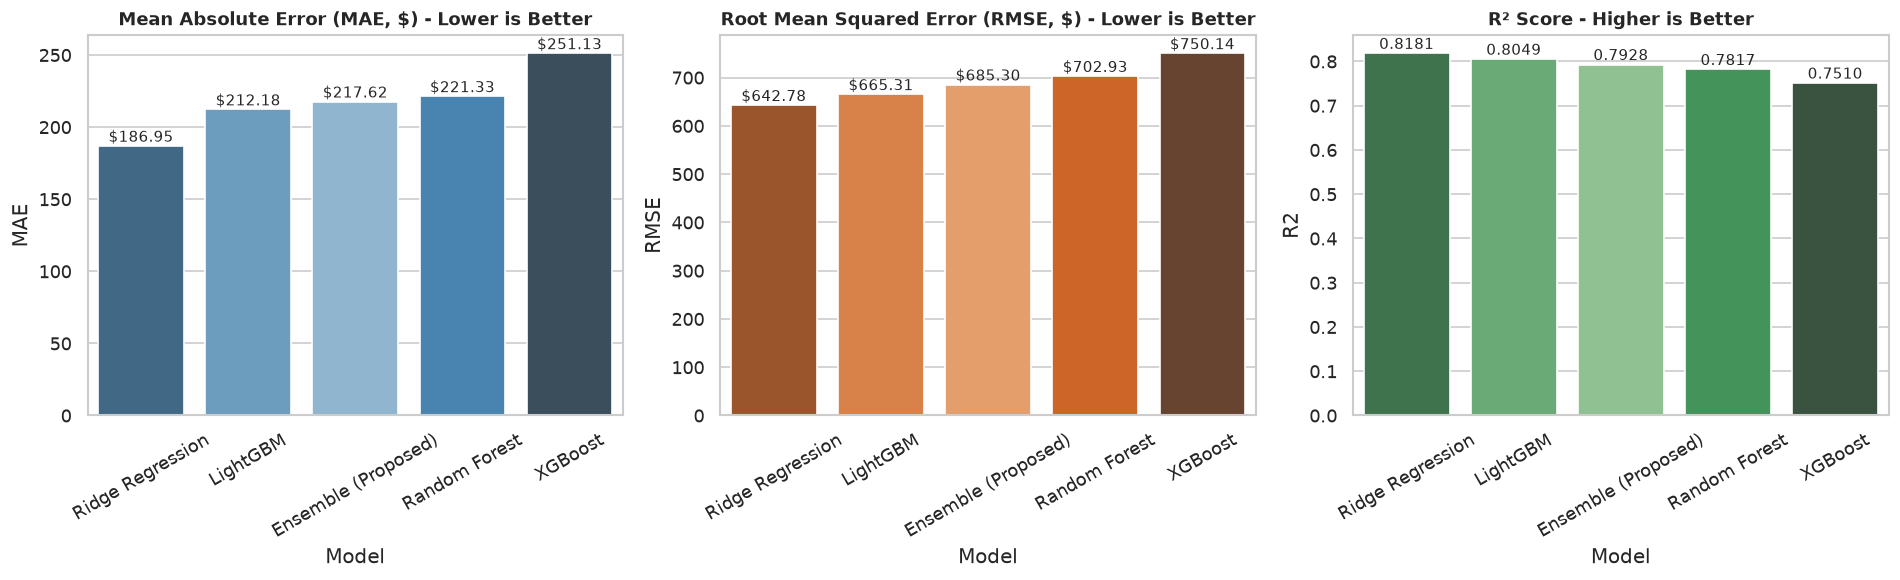

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=120)
model_order = ['Ridge Regression', 'LightGBM', 'Ensemble (Proposed)', 'Random Forest', 'XGBoost']

# MAE
sns.barplot(data=summary_metrics, x='Model', y='MAE', order=model_order, ax=axes[0], hue='Model', palette='Blues_d', legend=False)
axes[0].set_title('Mean Absolute Error (MAE, $) - Lower is Better', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f"${p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

# RMSE
sns.barplot(data=summary_metrics, x='Model', y='RMSE', order=model_order, ax=axes[1], hue='Model', palette='Oranges_d', legend=False)
axes[1].set_title('Root Mean Squared Error (RMSE, $) - Lower is Better', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f"${p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

# R2
sns.barplot(data=summary_metrics, x='Model', y='R2', order=model_order, ax=axes[2], hue='Model', palette='Greens_d', legend=False)
axes[2].set_title('R² Score - Higher is Better', fontsize=11, fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches='tight')
plt.show()

## 5. Feature Importance Analysis

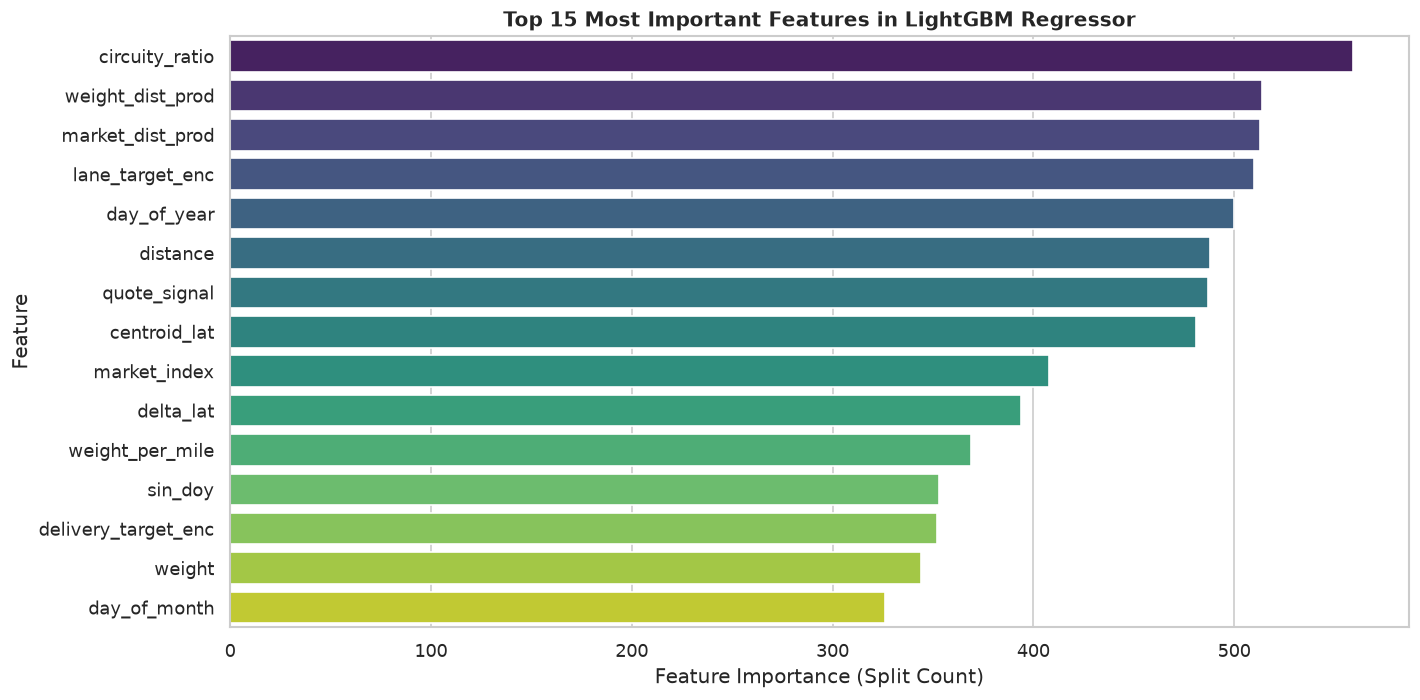

In [42]:
# Train LightGBM to analyze feature importances
lgbm_exp = lgb.LGBMRegressor(n_estimators=350, learning_rate=0.05, max_depth=8, num_leaves=31, random_state=42, verbose=-1)
lgbm_exp.fit(X, y)

feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': lgbm_exp.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6), dpi=120)
sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Most Important Features in LightGBM Regressor', fontweight='bold', fontsize=12)
plt.xlabel('Feature Importance (Split Count)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 6. Production Model Retraining & Prediction Export

In [41]:
print("Retraining final production ensemble on all clean training data (Jan-Oct 2025)...")
final_lgbm = lgb.LGBMRegressor(n_estimators=350, learning_rate=0.05, max_depth=8, num_leaves=31, random_state=42, verbose=-1)
final_xgb = xgb.XGBRegressor(n_estimators=350, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
final_rf = RandomForestRegressor(n_estimators=120, max_depth=12, random_state=42, n_jobs=-1)

final_lgbm.fit(X, y)
final_xgb.fit(X, y)
final_rf.fit(X, y)

val_preds = 0.45 * final_lgbm.predict(X_val) + 0.45 * final_xgb.predict(X_val) + 0.10 * final_rf.predict(X_val)
dec_preds = 0.45 * final_lgbm.predict(X_dec) + 0.45 * final_xgb.predict(X_dec) + 0.10 * final_rf.predict(X_dec)

val_preds = np.clip(val_preds, a_min=100.0, a_max=None)
dec_preds = np.clip(dec_preds, a_min=100.0, a_max=None)

# 1. Export validation predictions
val_predictions_df = pd.DataFrame({
    'load_id': val_raw['load_id'],
    'predicted_rate': val_preds
})
val_predictions_df.to_csv('validation_predictions.csv', index=False)
print(f"Saved {len(val_predictions_df):,} validation predictions to validation_predictions.csv")

# 2. Update December chart inputs
dec_raw['predicted_rate'] = dec_preds
dec_out_df = dec_raw[['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']].copy()
dec_out_df['date'] = pd.to_datetime(dec_out_df['date']).dt.strftime('%Y-%m-%d')
dec_out_df.to_csv('december-chart-inputs.csv', index=False)
print(f"Updated december-chart-inputs.csv with clean December predictions.")

Retraining final production ensemble on all clean training data (Jan-Oct 2025)...
Saved 12,000 validation predictions to validation_predictions.csv
Updated december-chart-inputs.csv with clean December predictions.


## 7. Official Repository Validator (`score.py`) & December Chart

In [43]:
!python score.py --predictions validation_predictions.csv --december-predictions december-chart-inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.


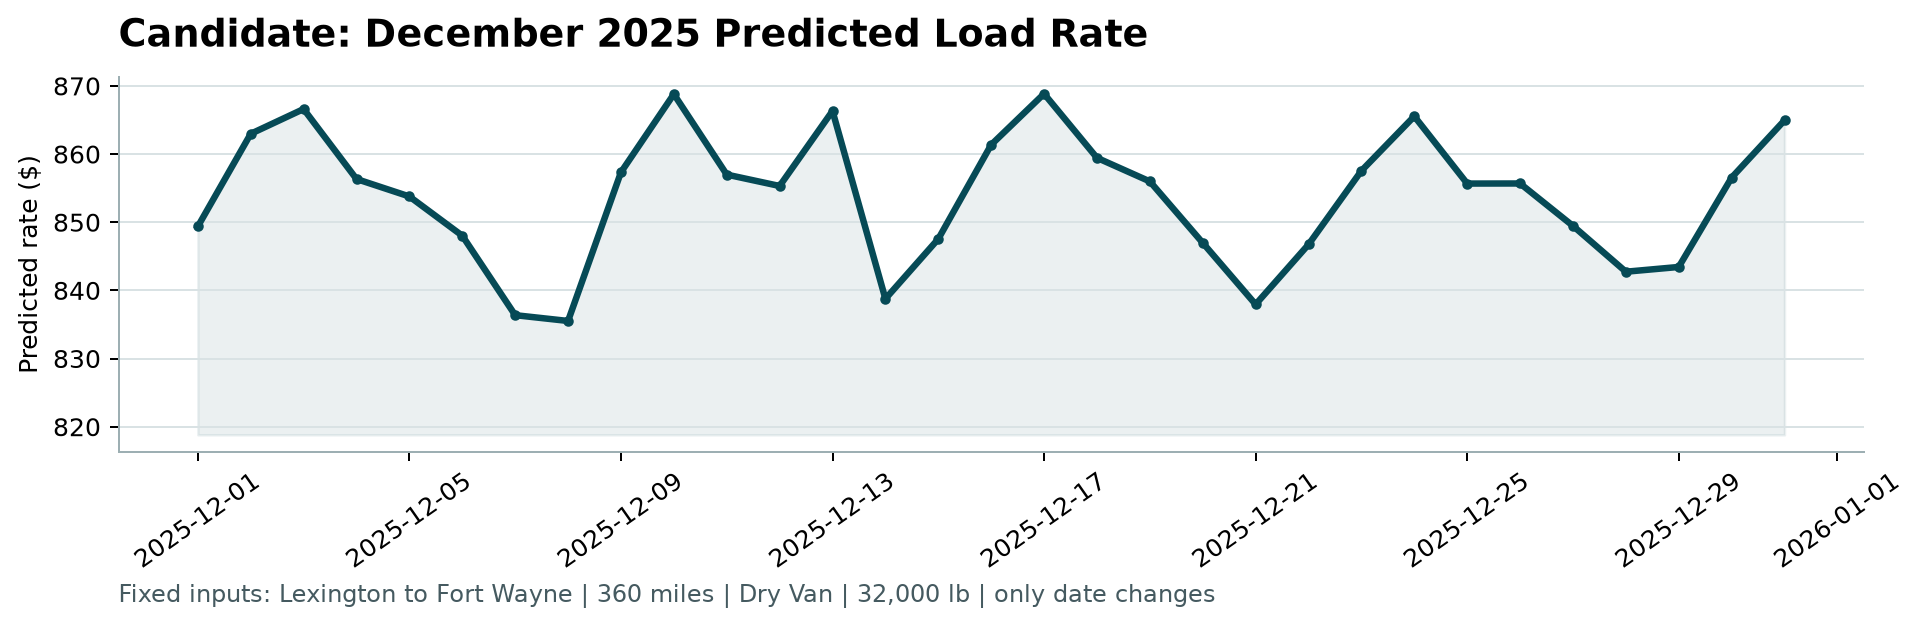

In [44]:
# Display the official candidate December prediction chart
display(Image(filename='scorer_results/candidate_december.png'))